In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
import warnings
warnings.filterwarnings('ignore')

# AI Data

## MFCCs: Extracting and Storing Features for All Songs

In [3]:
#Define audio directory
AI_audio_dir = 'data/AI'

#List of all the AI audio files
AI_audio_files = os.listdir(AI_audio_dir)

In [ ]:
# Function to extract MFCC features and calculate the mean
def extract_mfcc_mean(file_path):
    """Extracts MFCC features and computes the mean."""
    try:
        # Load the audio file
        y, sr = librosa.load(file_path, mono=True, duration=30)
        # Extract MFCC features
        mfccs = librosa.feature.mfcc(y=y, sr=sr)
        # Compute the mean of the MFCCs across all frames
        mfccs_mean = np.mean(mfccs.T, axis=0)
        return mfccs_mean
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Initialize lists to store data
AI_mfccs_list = []
song_names = []

# Loop through each file in the directory
for filename in AI_audio_files:
    if filename.endswith('.mp3'):
        file_path = os.path.join(AI_audio_dir, filename)
        mfcc_features = extract_mfcc_mean(file_path)
        
        if mfcc_features is not None:
            AI_mfccs_list.append(mfcc_features)
            song_names.append(filename)

# Create a pandas DataFrame
# Each row will be a song, and each column an MFCC feature
AI_mfccs_df = pd.DataFrame(AI_mfccs_list)

# Set the song filenames as the index for easier identification
AI_mfccs_df.index = song_names

# Add column names for the MFCC coefficients
# Assuming 20 MFCCs are returned by default by librosa
AI_mfccs_df.columns = [f'mfcc_{i}' for i in range(AI_mfccs_df.shape[1])]

# DataFrame to a CSV file
AI_mfccs_df.to_csv('AI_mfcc_features.csv')

## MFCCs Exploratory Data Analysis

In [ ]:
AI_mfcc_explore = AI_mfccs_df
#Compute mean for every row

AI_mfcc_explore["mean"] = AI_mfccs_df.mean(axis=1)
AI_mfcc_explore["std"] = AI_mfccs_df.std(axis=1)

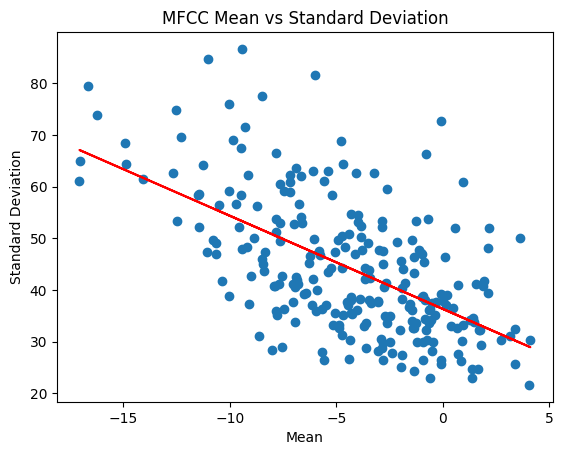

In [65]:
#Plot the mfcc means vs the mfcc std
mfcc_x = AI_mfcc_explore["mean"]
mfcc_y = AI_mfcc_explore["std"]

#Calculate line of best fit
z = np.polyfit(mfcc_x, mfcc_y, 1)
p = np.poly1d(z)

fig, ax = plt.subplots()
ax.scatter(mfcc_x, mfcc_y)
plt.plot(mfcc_x, p(mfcc_x), "r-")
ax.set_xlabel("Mean")
ax.set_ylabel("Standard Deviation")
ax.set_title("MFCC Mean vs Standard Deviation")
plt.show()

### Interpretation

The MFCCs capture the "texture" of the sound, which involves frequency. The mean is the average frequency level, while the standard deviation is the amount of variation in the frequency levels. The songs are pretty evenly spread out, which indicates various genres in the songs, since there are various frequency ranges represented.

## Tempogram: Extracting and Storing Features for All Songs

In [ ]:
# Function to extract tempo
def extract_tempo(file_path):
    """Extracts the estimated tempo (BPM) from an audio file."""
    try:
        y, sr = librosa.load(file_path, mono=True, duration=30)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        return tempo
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Initialize
AI_tempo_list = []
song_names = []

# Loop through each file
for filename in AI_audio_files:
    if filename.endswith('.mp3'):
        file_path = os.path.join(AI_audio_dir, filename)
        tempo = extract_tempo(file_path)

        if tempo is not None:
            AI_tempo_list.append(tempo)
            song_names.append(filename)

# Create DataFrame
AI_tempo_df = pd.DataFrame({'song_name': song_names, 'tempo_bpm': AI_tempo_list})
AI_tempo_df.set_index('song_name', inplace=True)

#Convert BPM to int
AI_tempo_df["tempo_bpm"] = AI_tempo_df["tempo_bpm"].astype(int)

# Save to CSV
AI_tempo_df.to_csv('AI_tempo_features.csv')

## Tempo Exploratory Data Analysis

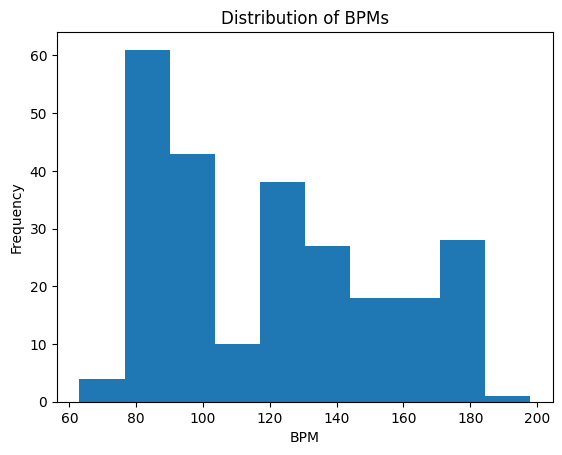

In [66]:
#Plot the tempo distribution

tempo_data = AI_tempo_df["tempo_bpm"]
tempo_data = tempo_data.astype(int)

fig, ax = plt.subplots()
ax.hist(tempo_data)

ax.set_xlabel("BPM")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of BPMs")
plt.show()

### Interpretation

There's a slightly right skew distribution in the AI music, meaning that AI songs tend to have a lower BPM.

## Chroma

In [ ]:
# Function to extract chroma features and compute their mean
def extract_chroma_mean(file_path):
    """Extracts chroma features and computes their mean across frames."""
    try:
        y, sr = librosa.load(file_path, mono=True, duration=30)
        S = np.abs(librosa.stft(y, n_fft=4096))**2
        chroma = librosa.feature.chroma_stft(S=S, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)
        return chroma_mean
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Initialize lists
AI_chroma_list = []
song_names = []

# Loop through files
for filename in AI_audio_files:
    if filename.endswith('.mp3'):
        file_path = os.path.join(AI_audio_dir, filename)
        chroma_features = extract_chroma_mean(file_path)

        if chroma_features is not None:
            AI_chroma_list.append(chroma_features)
            song_names.append(filename)

# Create DataFrame
AI_chroma_df = pd.DataFrame(AI_chroma_list, index=song_names)
AI_chroma_df.columns = [f'chroma_{i}' for i in range(AI_chroma_df.shape[1])]

# Save to file
AI_chroma_df.to_csv('AI_chroma_features.csv')

## Chroma Exploratory Data Analysis

In [67]:
AI_chroma_explore = AI_chroma_df
#Compute mean for every row

AI_chroma_explore["mean"] = AI_chroma_df.mean(axis=1)
AI_chroma_explore["std"] = AI_chroma_df.std(axis=1)

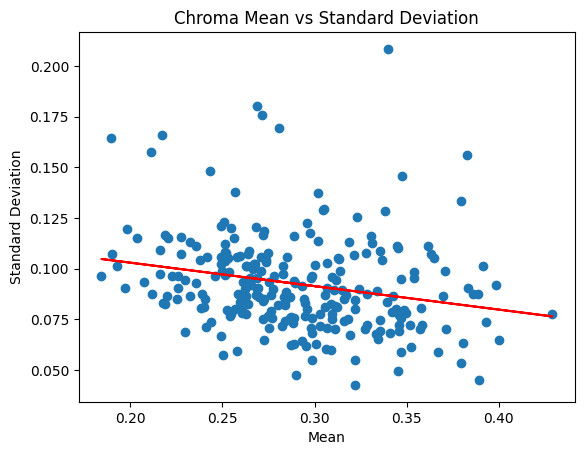

In [68]:
#Plot the chroma means vs the chroma std
chroma_x = AI_chroma_explore["mean"]
chroma_y = AI_chroma_explore["std"]

#Calculate line of best fit
z = np.polyfit(chroma_x, chroma_y, 1)
p = np.poly1d(z)

fig, ax = plt.subplots()
ax.scatter(chroma_x, chroma_y)
plt.plot(chroma_x, p(chroma_x), "r-")
ax.set_xlabel("Mean")
ax.set_ylabel("Standard Deviation")
ax.set_title("Chroma Mean vs Standard Deviation")
plt.show()

### Interpretation

Chroma is the aggregation of octaves, so the mean chroma vector summarizes the melodic contents of the audio. Chroma is usually mapped onto key. More simply, chroma is how harmoniously consistent the song is. There is a weak negative correlation with chroma mean and chroma standard deviation. The chroma means indicate that the songs have a mix of lots of tones or a balanced harmonious structure, so it doesn't have a clearly defined key. The chroma standard deviation means that the key strength doesn't vary much from the average.  

## Concat All AI_DFs

In [ ]:
# --- Load feature DataFrames ---
AI_mfcc_df = pd.read_csv('AI_mfcc_features.csv', index_col=0)
AI_tempo_df = pd.read_csv('AI_tempo_features.csv', index_col=0)
AI_chroma_df = pd.read_csv('AI_chroma_features.csv', index_col=0)

# --- Clean up names ---
AI_mfcc_df.index = AI_mfcc_df.index.str.replace('.mp3', '', regex=False)
AI_tempo_df.index = AI_tempo_df.index.str.replace('.mp3', '', regex=False)
AI_chroma_df.index = AI_chroma_df.index.str.replace('.mp3', '', regex=False)

# --- Combine feature DataFrames (keeping song_name as index) ---
combined_AI_features_df = AI_mfcc_df.join(AI_tempo_df, how='outer')
combined_AI_features_df = combined_AI_features_df.join(AI_chroma_df, how='outer')

combined_AI_features_df["is_ai"] = 1

#Save to CSV
combined_AI_features_df.to_csv('combined_AI_features.csv')

# Training Data

## MFCCs: Extracting and Storing Features for All Songs

In [ ]:
#Define audio directory
Spotify_audio_dir = 'data/Spotify'

#List of all the AI audio files
Spotify_audio_files = os.listdir(Spotify_audio_dir)

In [ ]:
# Function to extract MFCC features and calculate the mean
def extract_mfcc_mean(file_path):
    """Extracts MFCC features and computes the mean."""
    try:
        # Load the audio file
        y, sr = librosa.load(file_path, mono=True, duration=30)
        # Extract MFCC features
        mfccs = librosa.feature.mfcc(y=y, sr=sr)
        # Compute the mean of the MFCCs across all frames
        mfccs_mean = np.mean(mfccs.T, axis=0)
        return mfccs_mean
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Initialize lists to store data
Spotify_mfccs_list = []
song_names = []

# Loop through each file in the directory
for filename in Spotify_audio_files:
    if filename.endswith('.mp3'):
        file_path = os.path.join(Spotify_audio_dir, filename)
        mfcc_features = extract_mfcc_mean(file_path)
        
        if mfcc_features is not None:
            Spotify_mfccs_list.append(mfcc_features)
            song_names.append(filename)

# Create a pandas DataFrame
# Each row will be a song, and each column an MFCC feature
Spotify_mfccs_df = pd.DataFrame(Spotify_mfccs_list)

# Set the song filenames as the index for easier identification
Spotify_mfccs_df.index = song_names

# Add column names for the MFCC coefficients
# Assuming 20 MFCCs are returned by default by librosa
Spotify_mfccs_df.columns = [f'mfcc_{i}' for i in range(Spotify_mfccs_df.shape[1])]

# DataFrame to a CSV file
Spotify_mfccs_df.to_csv('Spotify_mfcc_features.csv')

## MFCCs Exploratory Data Analysis

In [ ]:
Spotify_mfcc_explore = Spotify_mfccs_df
#Compute mean for every row

Spotify_mfcc_explore["mean"] = Spotify_mfccs_df.mean(axis=1)
Spotify_mfcc_explore["std"] = Spotify_mfccs_df.std(axis=1)

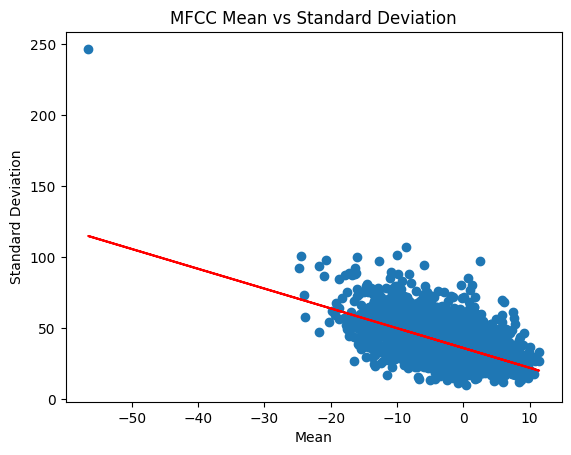

In [69]:
#Plot the mfcc means vs the mfcc std
mfcc_x = Spotify_mfcc_explore["mean"]
mfcc_y = Spotify_mfcc_explore["std"]

#Calculate line of best fit
z = np.polyfit(mfcc_x, mfcc_y, 1)
p = np.poly1d(z)

fig, ax = plt.subplots()
ax.scatter(mfcc_x, mfcc_y)
plt.plot(mfcc_x, p(mfcc_x), "r-")
ax.set_xlabel("Mean")
ax.set_ylabel("Standard Deviation")
ax.set_title("MFCC Mean vs Standard Deviation")
plt.show()

### Interpretation

The control mfcc MFCCs have a larger mean range and a larger standard deviation range than the AI mfccs, which could be due to the larger control sample size. The control MFCCs also have a moderate negative correlation. There is a potential outlier with the mean of about a -80 frequency distribution.

## Tempogram: Extracting and Storing Features for All Songs

In [ ]:
# Function to extract tempo
def extract_tempo(file_path):
    """Extracts the estimated tempo (BPM) from an audio file."""
    try:
        y, sr = librosa.load(file_path, mono=True, duration=30)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        return tempo
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Initialize
Spotify_tempo_list = []
song_names = []

# Loop through each file
for filename in Spotify_audio_files:
    if filename.endswith('.mp3'):
        file_path = os.path.join(Spotify_audio_dir, filename)
        tempo = extract_tempo(file_path)

        if tempo is not None:
            Spotify_tempo_list.append(tempo)
            song_names.append(filename)

# Create DataFrame
Spotify_tempo_df = pd.DataFrame({'song_name': song_names, 'tempo_bpm': Spotify_tempo_list})
Spotify_tempo_df.set_index('song_name', inplace=True)

#Convert BPM to int
Spotify_tempo_df["tempo_bpm"] = Spotify_tempo_df["tempo_bpm"].astype(int)

# Save to CSV
Spotify_tempo_df.to_csv('Spotify_tempo_features.csv')

## BPM Exploratory Data Analysis

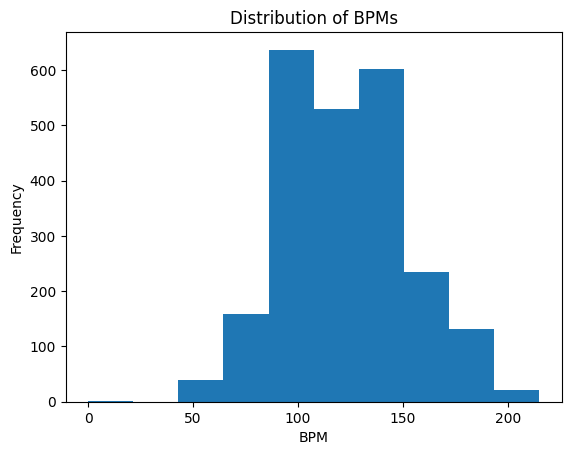

In [70]:
#Plot the tempo distribution

tempo_data = Spotify_tempo_df["tempo_bpm"]
tempo_data = tempo_data.astype(int)

fig, ax = plt.subplots()
ax.hist(tempo_data)

ax.set_xlabel("BPM")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of BPMs")
plt.show()

### Interpretation

The control BPMs are approximately normally distributed and centered around 120 BPM, which is faster on average than the AI songs.

## Chroma: Extracting and Storing Features for All Songs

In [ ]:
# Function to extract chroma features and compute their mean
def extract_chroma_mean(file_path):
    """Extracts chroma features and computes their mean across frames."""
    try:
        y, sr = librosa.load(file_path, mono=True, duration=30)
        S = np.abs(librosa.stft(y, n_fft=4096))**2
        chroma = librosa.feature.chroma_stft(S=S, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)
        return chroma_mean
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Initialize lists
Spotify_chroma_list = []
song_names = []

# Loop through files
for filename in Spotify_audio_files:
    if filename.endswith('.mp3'):
        file_path = os.path.join(Spotify_audio_dir, filename)
        chroma_features = extract_chroma_mean(file_path)

        if chroma_features is not None:
            Spotify_chroma_list.append(chroma_features)
            song_names.append(filename)

# Create DataFrame
Spotify_chroma_df = pd.DataFrame(Spotify_chroma_list, index=song_names)
Spotify_chroma_df.columns = [f'chroma_{i}' for i in range(Spotify_chroma_df.shape[1])]

# Save to file
Spotify_chroma_df.to_csv('Spotify_chroma_features.csv')

## Chroma Exploratory Data Analysis

In [ ]:
Spotify_chroma_explore = Spotify_chroma_df
#Compute mean for every row

Spotify_chroma_explore["mean"] = Spotify_chroma_df.mean(axis=1)
Spotify_chroma_explore["std"] = Spotify_chroma_df.std(axis=1)

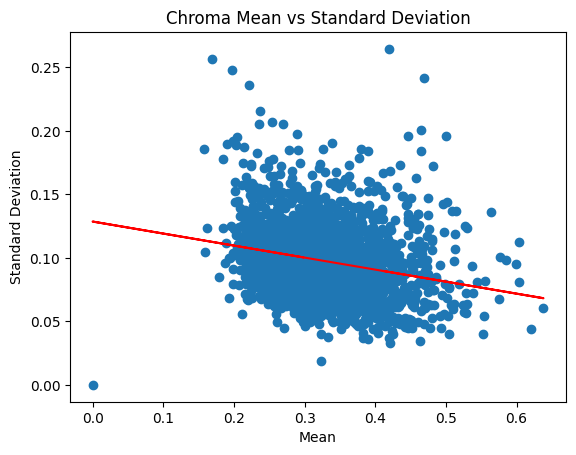

In [71]:
#Plot the chroma means vs the chroma std
chroma_x = Spotify_chroma_explore["mean"]
chroma_y = Spotify_chroma_explore["std"]

#Calculate line of best fit
z = np.polyfit(chroma_x, chroma_y, 1)
p = np.poly1d(z)

fig, ax = plt.subplots()
ax.scatter(chroma_x, chroma_y)
plt.plot(chroma_x, p(chroma_x), "r-")
ax.set_xlabel("Mean")
ax.set_ylabel("Standard Deviation")
ax.set_title("Chroma Mean vs Standard Deviation")
plt.show()

### Interpretation

The chroma means and standard deviations also have more variation than the AI songs, which could be due to the larger control sample size or human creativity. The chroma means range from 0.15-0.65 indicates that the songs have a large key variation to have a moderately strong key. The chroma standard deviations range indicates that there is a greater variation of the mean key variation.

## Concat All Spotify_DFs

In [ ]:
# --- Load feature DataFrames ---
spotify_mfcc_df = pd.read_csv('Spotify_mfcc_features.csv', index_col=0)
spotify_tempo_df = pd.read_csv('Spotify_tempo_features.csv', index_col=0)
spotify_chroma_df = pd.read_csv('Spotify_chroma_features.csv', index_col=0)

# --- Clean up names ---
spotify_mfcc_df.index = spotify_mfcc_df.index.str.replace('.mp3', '', regex=False)
spotify_tempo_df.index = spotify_tempo_df.index.str.replace('.mp3', '', regex=False)
spotify_chroma_df.index = spotify_chroma_df.index.str.replace('.mp3', '', regex=False)

# --- Combine feature DataFrames (keeping song_name as index) ---
combined_spotify_features_df = spotify_mfcc_df.join(spotify_tempo_df, how='outer')
combined_spotify_features_df = combined_spotify_features_df.join(spotify_chroma_df, how='outer')

combined_spotify_features_df["is_ai"] = 0

#Save to CSV
combined_spotify_features_df.to_csv('combined_spotify_features.csv')

# Test Data

## MFCCs: Extracting and Storing Features for All Songs

In [ ]:
#Define audio directory
Control_audio_dir = 'data/Control'

#List of all the AI audio files
Control_audio_files = os.listdir(Control_audio_dir)

In [ ]:
# Function to extract MFCC features and calculate the mean
def extract_mfcc_mean(file_path):
    """Extracts MFCC features and computes the mean."""
    try:
        # Load the audio file
        y, sr = librosa.load(file_path, mono=True, duration=30)
        # Extract MFCC features
        mfccs = librosa.feature.mfcc(y=y, sr=sr)
        # Compute the mean of the MFCCs across all frames
        mfccs_mean = np.mean(mfccs.T, axis=0)
        return mfccs_mean
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Initialize lists to store data
Control_mfccs_list = []
song_names = []

# Loop through each file in the directory
for filename in Control_audio_files:
    if filename.endswith('.mp3'):
        file_path = os.path.join(Control_audio_dir, filename)
        mfcc_features = extract_mfcc_mean(file_path)
        
        if mfcc_features is not None:
            Control_mfccs_list.append(mfcc_features)
            song_names.append(filename)

# Create a pandas DataFrame
# Each row will be a song, and each column an MFCC feature
Control_mfccs_df = pd.DataFrame(Control_mfccs_list)

# Set the song filenames as the index for easier identification
Control_mfccs_df.index = song_names

# Add column names for the MFCC coefficients
# Assuming 20 MFCCs are returned by default by librosa
Control_mfccs_df.columns = [f'mfcc_{i}' for i in range(Control_mfccs_df.shape[1])]


# DataFrame to a CSV file
Control_mfccs_df.to_csv('Control_mfcc_features.csv')

## MFCCs Exploratory Data Analysis

In [ ]:
Control_mfcc_explore = Control_mfccs_df
#Compute mean for every row

Control_mfcc_explore["mean"] = Control_mfccs_df.mean(axis=1)
Control_mfcc_explore["std"] = Control_mfccs_df.std(axis=1)

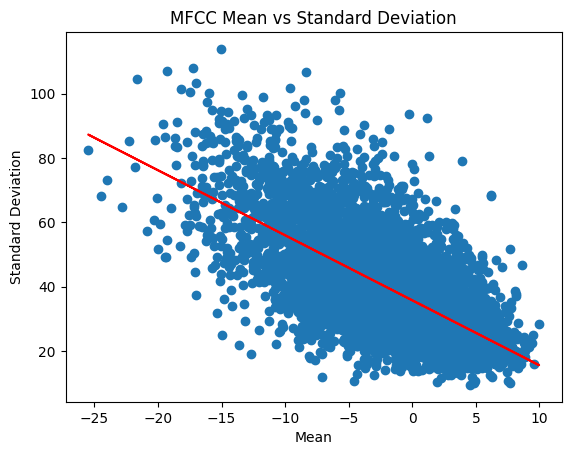

In [72]:
#Plot the mfcc means vs the mfcc std
mfcc_x = Control_mfcc_explore["mean"]
mfcc_y = Control_mfcc_explore["std"]

#Calculate line of best fit
z = np.polyfit(mfcc_x, mfcc_y, 1)
p = np.poly1d(z)

fig, ax = plt.subplots()
ax.scatter(mfcc_x, mfcc_y)
plt.plot(mfcc_x, p(mfcc_x), "r-")
ax.set_xlabel("Mean")
ax.set_ylabel("Standard Deviation")
ax.set_title("MFCC Mean vs Standard Deviation")
plt.show()

### Interpretation

There is a strong negative correlation with MFCC mean and standard deviation. This is the greatest MFCC mean variation, which is a testament to the frequency variation in the top Spotify songs. Frequency variations indicate different genres. The MFCC standard deviation range for Spotify is about the same as the range for the control set.

## Tempogram: Extracting and Storing Features for All Songs

In [ ]:
# Function to extract tempo
def extract_tempo(file_path):
    """Extracts the estimated tempo (BPM) from an audio file."""
    try:
        y, sr = librosa.load(file_path, mono=True, duration=30)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        return tempo
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Initialize
Control_tempo_list = []
song_names = []

# Loop through each file
for filename in Control_audio_files:
    if filename.endswith('.mp3'):
        file_path = os.path.join(Control_audio_dir, filename)
        tempo = extract_tempo(file_path)

        if tempo is not None:
            Control_tempo_list.append(tempo)
            song_names.append(filename)

# Create DataFrame
Control_tempo_df = pd.DataFrame({'song_name': song_names, 'tempo_bpm': Control_tempo_list})
Control_tempo_df.set_index('song_name', inplace=True)


#Convert BPM to int
Control_tempo_df["tempo_bpm"] = Control_tempo_df["tempo_bpm"].astype(int)

# Save to CSV
Control_tempo_df.to_csv('Control_tempo_features.csv')

## Tempo Exploratory Data Analysis

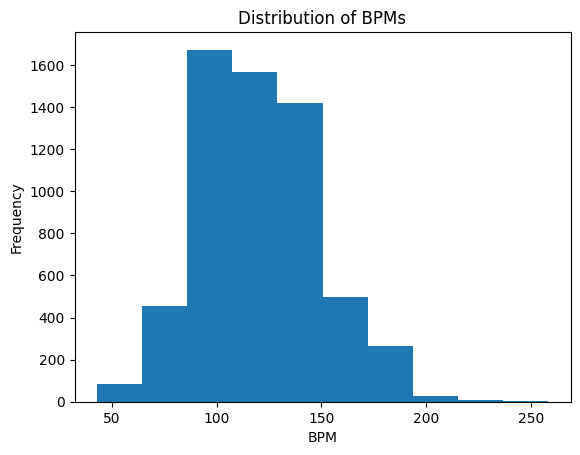

In [73]:
#Plot the tempo distribution

tempo_data = Control_tempo_df["tempo_bpm"]
tempo_data = tempo_data.astype(int)

fig, ax = plt.subplots()
ax.hist(tempo_data)

ax.set_xlabel("BPM")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of BPMs")
plt.show()

### Interpretation

The Spotify BPMs are approximately normally distributed and centered at 100 BPM. The Spotify set is more balanced than the control set and slower overall.

## Chroma: Extracting and Storing Features for All Songs

In [ ]:
# Function to extract chroma features and compute their mean
def extract_chroma_mean(file_path):
    """Extracts chroma features and computes their mean across frames."""
    try:
        y, sr = librosa.load(file_path, mono=True, duration=30)
        S = np.abs(librosa.stft(y, n_fft=4096))**2
        chroma = librosa.feature.chroma_stft(S=S, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)
        return chroma_mean
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Initialize lists
Control_chroma_list = []
song_names = []

# Loop through files
for filename in Control_audio_files:
    if filename.endswith('.mp3'):
        file_path = os.path.join(Control_audio_dir, filename)
        chroma_features = extract_chroma_mean(file_path)

        if chroma_features is not None:
            Control_chroma_list.append(chroma_features)
            song_names.append(filename)

# Create DataFrame
Control_chroma_df = pd.DataFrame(Control_chroma_list, index=song_names)
Control_chroma_df.columns = [f'chroma_{i}' for i in range(Control_chroma_df.shape[1])]

# Save to file
Control_chroma_df.to_csv('Control_chroma_features.csv')

## Chroma Exploratory Data Analysis

In [ ]:
Control_chroma_explore = Control_chroma_df
#Compute mean for every row

Control_chroma_explore["mean"] = Control_chroma_df.mean(axis=1)
Control_chroma_explore["std"] = Control_chroma_df.std(axis=1)

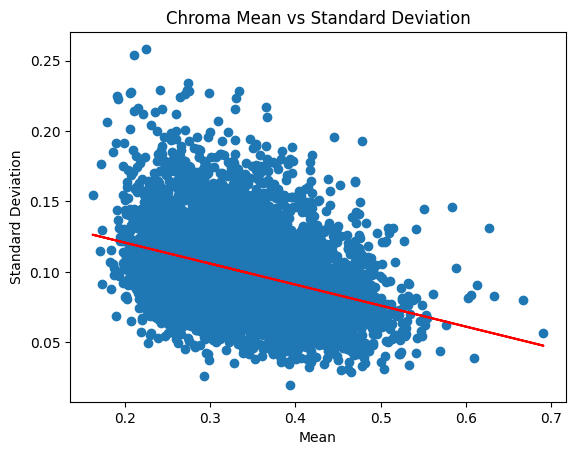

In [74]:
#Plot the chroma means vs the chroma std
chroma_x = Control_chroma_explore["mean"]
chroma_y = Control_chroma_explore["std"]

#Calculate line of best fit
z = np.polyfit(chroma_x, chroma_y, 1)
p = np.poly1d(z)

fig, ax = plt.subplots()
ax.scatter(chroma_x, chroma_y)
plt.plot(chroma_x, p(chroma_x), "r-")
ax.set_xlabel("Mean")
ax.set_ylabel("Standard Deviation")
ax.set_title("Chroma Mean vs Standard Deviation")
plt.show()

### Interpretation

The chroma has a weak negative correlation. The Spotify chroma mean range is less than the control mean range, meaning that on average, the songs have a less consistent key. The Spotify chroma standard deviation also has a slightly greater range than the control chroma standard deviation range. Like the MFCCs, this may be due to the genre variation.

## Concat All Control_DFs

In [ ]:
# --- Load feature DataFrames ---
Control_mfcc_df = pd.read_csv('Control_mfcc_features.csv', index_col=0)
Control_tempo_df = pd.read_csv('Control_tempo_features.csv', index_col=0)
Control_chroma_df = pd.read_csv('Control_chroma_features.csv', index_col=0)

# --- Clean up names ---
Control_mfcc_df.index = Control_mfcc_df.index.str.replace('.mp3', '', regex=False)
Control_tempo_df.index = Control_tempo_df.index.str.replace('.mp3', '', regex=False)
Control_chroma_df.index = Control_chroma_df.index.str.replace('.mp3', '', regex=False)

# --- Combine feature DataFrames (keeping song_name as index) ---
combined_control_features_df = Control_mfcc_df.join(Control_tempo_df, how='outer')
combined_control_features_df = combined_control_features_df.join(Control_chroma_df, how='outer')

combined_control_features_df["is_ai"] = 0

#Save to CSV
combined_control_features_df.to_csv('combined_control_features.csv')

# Remove Duplicates from Training and Test Data

In [ ]:
#combined_spotify_features_df is training
#combined_control_features_df is test

common_indices = set(combined_spotify_features_df.index).intersection(set(combined_control_features_df.index))

# Remove common indices from test data
combined_control_features_df_clean = combined_control_features_df.drop(common_indices)

## Comparison

In [ ]:
#combined_human_df = mfcc_df.join(tempo_df, how='outer')

all_songs_df = pd.concat([combined_AI_features_df, combined_control_features_df_clean, combined_spotify_features_df])

In [ ]:
all_songs_df["is_ai"] = all_songs_df["is_ai"].fillna(0).astype(int)

In [ ]:
X = all_songs_df.drop(columns=["is_ai"])
y = all_songs_df["is_ai"]

cos_sim_matrix = cosine_similarity(X)
song_names = all_songs_df.index

In [ ]:
#Pairwise

pairs = []
max_pairs = 100_000 

indices = [(i, j) for i in range(len(song_names)) for j in range(i+1, len(song_names))]
sampled = np.random.choice(len(indices), size=max_pairs, replace=False)

for k in sampled:
    i, j = indices[k]
    s1, s2 = song_names[i], song_names[j]
    pairs.append({
        "song_a": s1,
        "song_b": s2,
        "similarity": cos_sim_matrix[i, j],
        "type_a": y.iloc[i],
        "type_b": y.iloc[j]
    })

pair_df = pd.DataFrame(pairs)

In [ ]:
#Save to csv
pair_df.to_csv("pair.csv")

In [75]:
pair_df.head(20)

,song_a,song_b,similarity,type_a,type_b,pair_type
0,Let It Go (DJ Boat Remix),Ring Ring Ring (Ha Ha Hey),0.865927,0,0,Human-Human
1,Hit Me With Your Best Shot,Rockaria!,0.981140,0,0,Human-Human
2,La player (Bandolera),The Chicken Wing Beat,0.976586,0,0,Human-Human
3,Beautiful (feat. Camila Cabello),Boys from the Bush,0.967577,0,0,Human-Human
4,Dreams - 2004 Remaster,Spectrum (Say My Name) - Calvin Harris Remix,0.917191,0,0,Human-Human
5,2012 Remaster,Flames,0.960987,0,0,Human-Human
6,Mess Her Up,Kernkraft 400 (A Better Day),0.892212,0,0,Human-Human
7,1979,Girl From Rio (feat. DaBaby) - TroyBoi Remix,0.653447,0,0,Human-Human
8,Lost It All,This Ain't A Love Song,0.962481,0,0,Human-Human
9,Malas Decisiones,Me Niego (feat. Ozuna & Wisin),0.921784,0,0,Human-Human


In [ ]:
#Categorize comparison types
pair_df["pair_type"] = pair_df.apply(
    lambda row: 
        "AI-AI" if row.type_a == 1 and row.type_b == 1 else
        "Human-Human" if row.type_a == 0 and row.type_b == 0 else
        "AI-Human",
    axis=1
)

In [76]:
pair_df.groupby("pair_type")["similarity"].mean()

pair_type
AI-AI          0.947579
AI-Human       0.911768
Human-Human    0.896209
Name: similarity, dtype: float64

### Interpretation

The AI pairs mean similarity having the highest mean similarity is consistent with our hypothesis that AI music is more similar on average to human music than human music is to each other.

In [77]:
def cohens_d(a, b):
    return (np.mean(a) - np.mean(b)) / np.sqrt((np.var(a) + np.var(b)) / 2)


In [78]:
d_ai_human = cohens_d(
    pair_df[pair_df.pair_type=="AI-AI"]["similarity"],
    pair_df[pair_df.pair_type=="AI-Human"]["similarity"]
)


In [79]:
d_ai_human

0.5451105675689177

### Interpretation

The AI similarity has a medium effect on the pairs dataset.

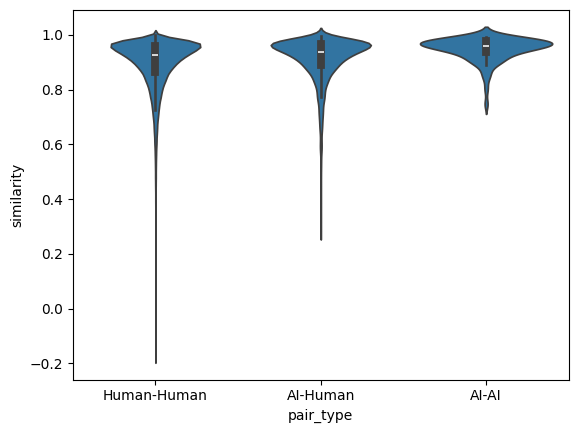

In [80]:
sns.violinplot(data=pair_df, x="pair_type", y="similarity")
plt.show()

### Interpretation

When the AI songs are compared to each other and to human songs, there is a lower variation of similarity, as supported by the Cohen's D of a moderate effect of AI songs on the similarity.

In [81]:
X = all_songs_df.drop(columns=['is_ai'])  # only features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit KMeans on X_scaled
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Silhouette score in FULL space
sil_score = silhouette_score(X_scaled, cluster_labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.1673750707808779


### Interpretation

The K-means clustering are to compare each similarity group, so that we can calculate the similarity within each of the clusters. The silhouette score evaluates how well the clustering was performed, which in this context means that each data point was weakly positively assigned to their similarity groups.

In [82]:
# PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = cluster_labels
pca_df["is_ai"] = all_songs_df["is_ai"].values

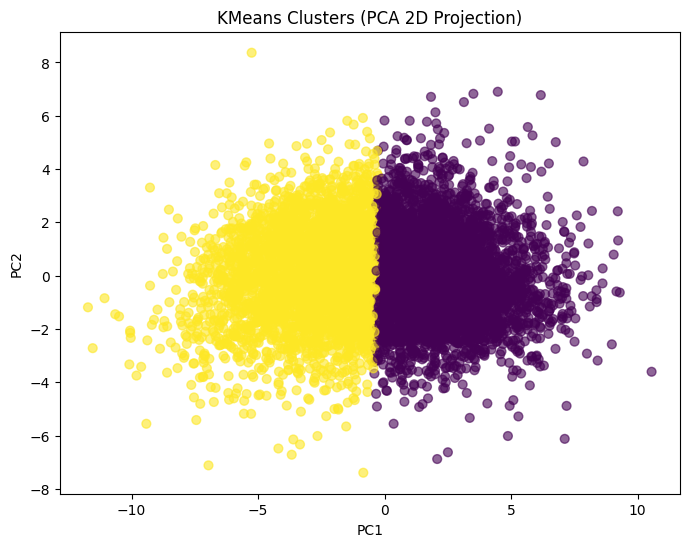

In [83]:
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_df["PC1"], pca_df["PC2"],
    c=pca_df["cluster"],
    alpha=0.6,
    s=40
)
plt.title("KMeans Clusters (PCA 2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### Interpretation

This is a visualization of the KMeans clusters. PCA was used to simplify the complexity of each data point, since each of these points have several audio features, that would complicate this analysis.

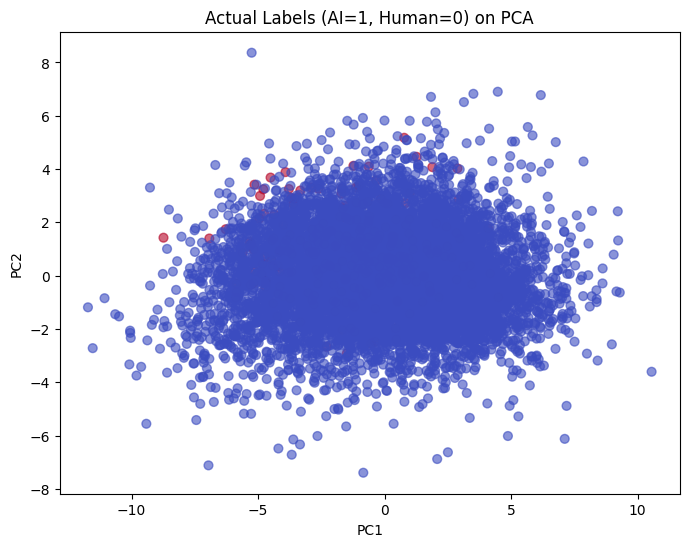

In [84]:
plt.figure(figsize=(8,6))
plt.scatter(
    pca_df["PC1"], pca_df["PC2"],
    c=pca_df["is_ai"],
    cmap="coolwarm",
    alpha=0.6,
    s=40
)
plt.title("Actual Labels (AI=1, Human=0) on PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### Interpretation

This visualization implies that AI songs are highly similar to human songs. Additionally, there is higher variation in the human songs than the AI songs, since they span across a wider area of the graph.

In [85]:
pd.crosstab(pca_df["is_ai"], pca_df["cluster"],
            rownames=["True Label"], colnames=["Cluster"])

pd.crosstab(pca_df["cluster"], pca_df["is_ai"]).T

cluster,0,1
is_ai,,
0,4583,3384
1,85,163


### Interpretation

This sampled pairs dataset overgeneralizes, probably due to the relatively low AI songs sample size. The most amount of human songs are correctly classified as humans, however a large amount of human songs are falsely classified as AI. The AI songs have similar human patterns. This statement is supported by the large amount of false positives of human songs being classified as AI.